# Netflix Content Analysis

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

NETFLIX_RED = "#E50914"
DARK_BG     = "#141414"
CARD_BG     = "#1F1F1F"
LIGHT_TEXT  = "#F5F5F1"
MUTED_TEXT  = "#999999"
ACCENT_GOLD = "#F5A623"
ACCENT_BLUE = "#5B9BD5"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor":   CARD_BG,
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  LIGHT_TEXT,
    "xtick.color":      MUTED_TEXT,
    "ytick.color":      MUTED_TEXT,
    "text.color":       LIGHT_TEXT,
    "grid.color":       "#2A2A2A",
    "grid.linewidth":   0.6,
    "font.family":      "sans-serif",
    "font.size":        11,
})

## Load Data

In [20]:
BASE = os.path.dirname(os.path.abspath("__file__"))
df = pd.read_excel(os.path.join(BASE, "4_6048713403436900891.xlsx"), parse_dates=["date_added"])
df["year_added"] = pd.to_datetime(df["date_added"], errors="coerce").dt.year
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Dick Johnson, Kirsten Johnson",United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,Nosipho Dumisa,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,Ramy Romany,"Megan Hawkins, Harley Himber",United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,Raghav Subbu,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [21]:
def save(fig, name):
    fig.savefig(f"{name}.png", dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

## Chart 1 - Movie Runtime by Rating (Box Plot)

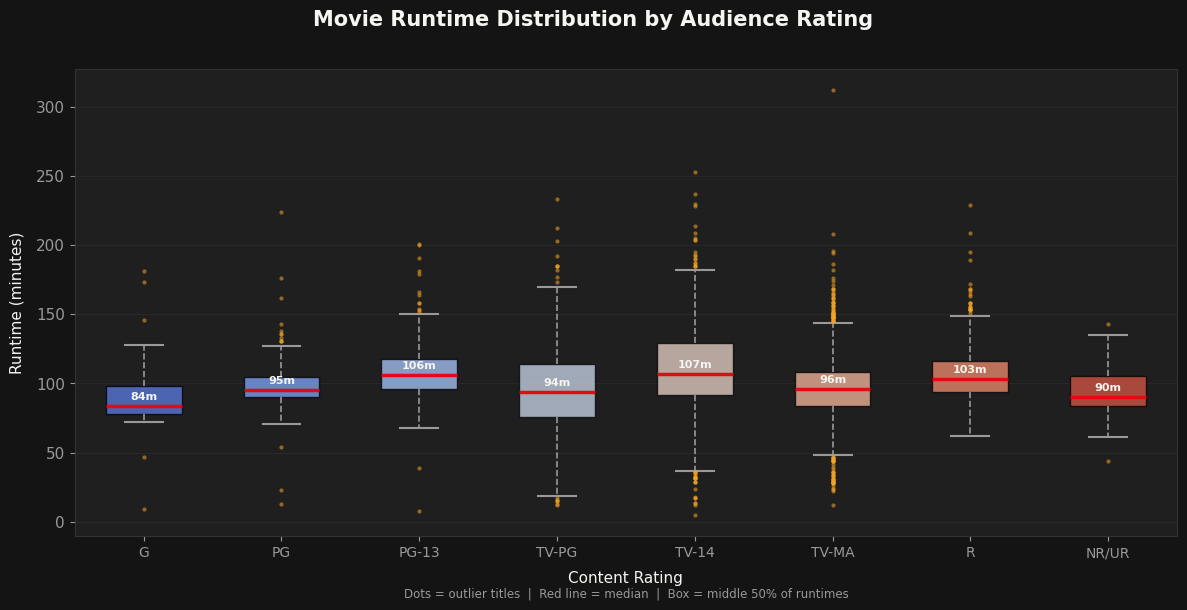

In [22]:
movies = df[df["type"] == "Movie"].copy()
movies["minutes"] = movies["duration"].str.extract(r"(\d+)").astype(float)

RATING_ORDER = ["G", "PG", "PG-13", "TV-PG", "TV-14", "TV-MA", "R", "NR"]
RATING_LABELS = {"G": "G", "PG": "PG", "PG-13": "PG-13", "TV-PG": "TV-PG",
                 "TV-14": "TV-14", "TV-MA": "TV-MA", "R": "R", "NR": "NR/UR"}

movies_rated = movies[movies["rating"].isin(RATING_ORDER)].copy()
movies_rated["rating_label"] = movies_rated["rating"].map(RATING_LABELS)

grouped = [
    movies_rated.loc[movies_rated["rating"] == r, "minutes"].dropna().values
    for r in RATING_ORDER
]

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Movie Runtime Distribution by Audience Rating",
             fontsize=15, fontweight="bold", color=LIGHT_TEXT, y=1.01)

bp = ax.boxplot(
    grouped,
    vert=True,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color=NETFLIX_RED, linewidth=2.5),
    whiskerprops=dict(color=MUTED_TEXT, linewidth=1.2, linestyle="--"),
    capprops=dict(color=MUTED_TEXT, linewidth=1.5),
    flierprops=dict(marker="o", markersize=3, markerfacecolor=ACCENT_GOLD,
                    markeredgewidth=0, alpha=0.55),
)

palette = sns.color_palette("coolwarm", len(RATING_ORDER))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(RATING_ORDER) + 1))
ax.set_xticklabels([RATING_LABELS[r] for r in RATING_ORDER], fontsize=10)
ax.set_ylabel("Runtime (minutes)", labelpad=8)
ax.set_xlabel("Content Rating", labelpad=8)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

for i, vals in enumerate(grouped, 1):
    if len(vals) > 0:
        med = np.median(vals)
        ax.text(i, med + 3, f"{med:.0f}m", ha="center", va="bottom",
                fontsize=8, color=LIGHT_TEXT, fontweight="bold")

ax.annotate("Dots = outlier titles  |  Red line = median  |  Box = middle 50% of runtimes",
            xy=(0.5, -0.13), xycoords="axes fraction",
            ha="center", fontsize=8.5, color=MUTED_TEXT)

fig.tight_layout()
save(fig, "1_movie_runtime_by_rating_boxplot")

## Chart 2 - Genre Volume by Year (Heatmap)

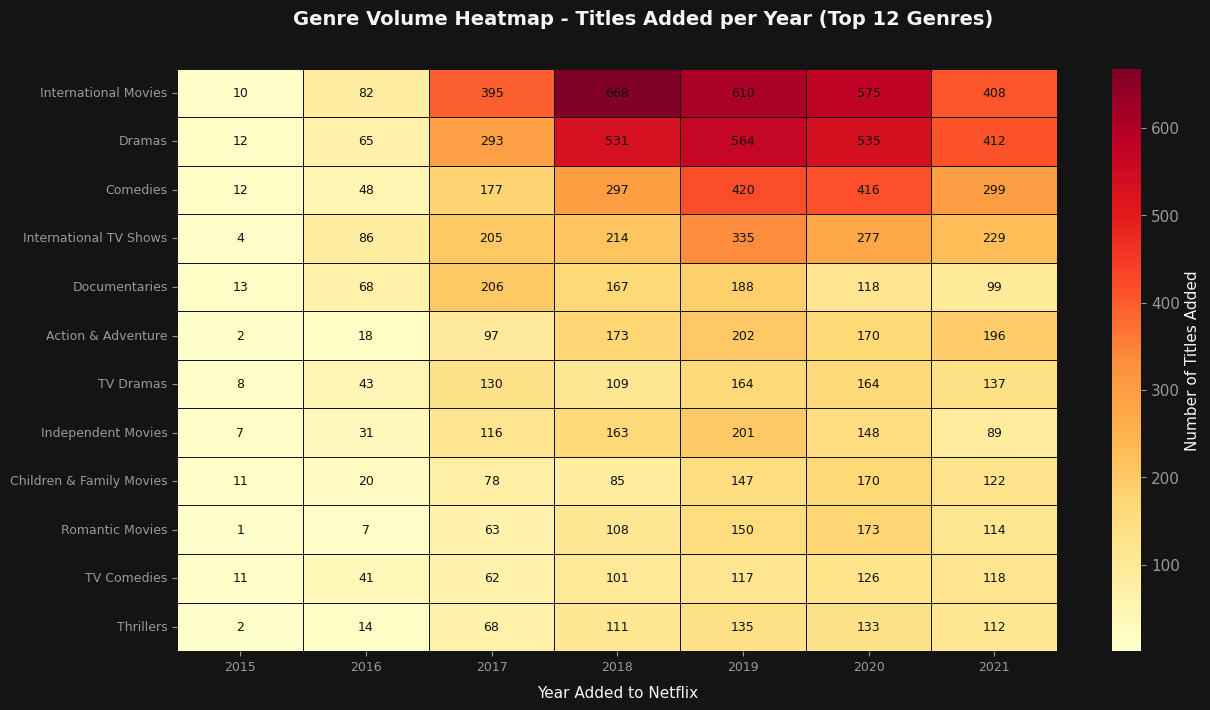

In [23]:
genre_df = df[df["year_added"].between(2015, 2021)].copy()
genre_df = genre_df.assign(genre=genre_df["listed_in"].str.split(", ")).explode("genre")

top_genres = genre_df["genre"].value_counts().head(12).index.tolist()

heat_data = (
    genre_df[genre_df["genre"].isin(top_genres)]
    .groupby(["year_added", "genre"])
    .size()
    .unstack(fill_value=0)
    .loc[2015:2021, top_genres]
    .T
)

fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle("Genre Volume Heatmap - Titles Added per Year (Top 12 Genres)",
             fontsize=14, fontweight="bold", color=LIGHT_TEXT, y=1.01)

sns.heatmap(heat_data, ax=ax, cmap="YlOrRd", linewidths=0.4, linecolor="#141414",
            annot=True, fmt="d", annot_kws={"size": 9, "color": "#111"},
            cbar_kws={"label": "Number of Titles Added"})

ax.set_xlabel("Year Added to Netflix", labelpad=8)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9, rotation=0)
ax.tick_params(axis="x", labelsize=9)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(LIGHT_TEXT)
cbar.ax.tick_params(colors=MUTED_TEXT)

fig.tight_layout()
save(fig, "2_genre_heatmap_by_year")

## Chart 3 - Top Countries: Movies vs TV Shows (Diverging Bar)

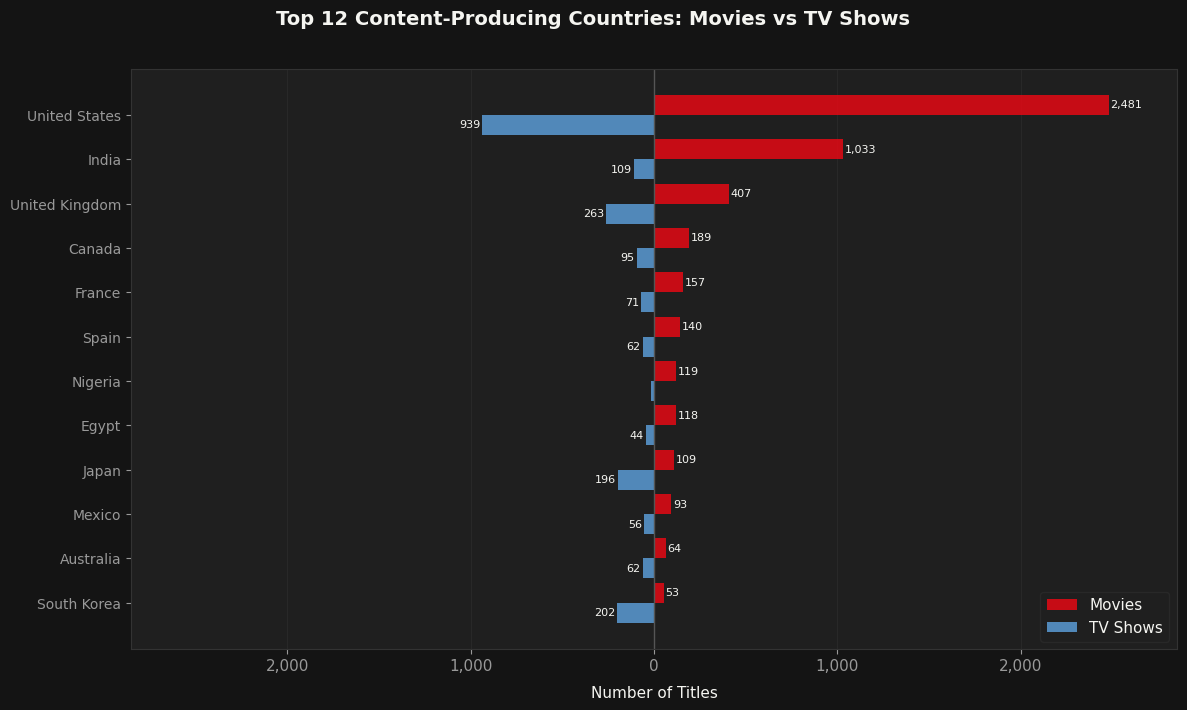

In [24]:
df["primary_country"] = df["country"].str.split(", ").str[0]

country_pivot = (
    df[df["primary_country"].notna()]
    .groupby(["primary_country", "type"])
    .size()
    .unstack(fill_value=0)
)

top_countries = country_pivot.sum(axis=1).nlargest(12).index
cp = country_pivot.loc[top_countries].sort_values("Movie")

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Top 12 Content-Producing Countries: Movies vs TV Shows",
             fontsize=14, fontweight="bold", color=LIGHT_TEXT, y=1.01)

y_pos = np.arange(len(cp))
bar_h = 0.45

bars_movies = ax.barh(y_pos + bar_h / 2, cp.get("Movie", 0),
                      height=bar_h, color=NETFLIX_RED, alpha=0.85, label="Movies")
bars_shows  = ax.barh(y_pos - bar_h / 2, -cp.get("TV Show", 0),
                      height=bar_h, color=ACCENT_BLUE, alpha=0.85, label="TV Shows")

ax.set_yticks(y_pos)
ax.set_yticklabels(cp.index, fontsize=10)
ax.axvline(0, color="#555", linewidth=1)

max_val = max(cp.get("Movie", pd.Series([0])).max(),
              cp.get("TV Show", pd.Series([0])).max())
ax.set_xlim(-max_val * 1.15, max_val * 1.15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(int(x)):,}"))
ax.set_xlabel("Number of Titles", labelpad=8)
ax.xaxis.grid(True)
ax.set_axisbelow(True)

for bar in bars_movies:
    w = bar.get_width()
    if w > 40:
        ax.text(w + 10, bar.get_y() + bar.get_height() / 2,
                f"{int(w):,}", va="center", fontsize=8, color=LIGHT_TEXT)

for bar in bars_shows:
    w = bar.get_width()
    if abs(w) > 40:
        ax.text(w - 10, bar.get_y() + bar.get_height() / 2,
                f"{abs(int(w)):,}", va="center", ha="right", fontsize=8, color=LIGHT_TEXT)

leg = ax.legend(loc="lower right", framealpha=0.25, facecolor=CARD_BG, edgecolor="#444")
for text in leg.get_texts():
    text.set_color(LIGHT_TEXT)

fig.tight_layout()
save(fig, "3_country_diverging_bar")